# Conditional gradient sliding algorithm
## Problem

We want to solve

$$\min\limits_{X\in\mathbb{R}^{n}} \frac{1}{2}\|Ax-b\|^2 + \iota_{\mathcal{C}}(x)$$

where $A\in\mathbb{R}^{m\times n}$ and

$$\mathcal{C} = \{x:\|x\|_1\leq \rho\}$$

The gradient of the objective function is given by

$$\nabla f(x) = A^*(Ax-b)$$

and the linear minimization oracle is just finding the largest entry of the gradient in magnitude.

We will use the so-called conditional gradient sliding algorithm.

## Conditional gradient sliding algorithm

### Algorithm

1. **Initialization**: 
   Choose an initial point $x_0 \in X$
   Set $y_0 = x_0$
   Choose step sizes $\{\beta_k\}$ and $\{\gamma_k\}$
   Set $k = 0$

2. **Main Loop**:
   For each iteration $k$:

   a) Compute $z_k$ (convex combination):
      $$z_k = (1 - \gamma_k)y_{k-1} + \gamma_k x_{k-1}$$

   b) Update $x_k$ (solve subproblem using CndG):
      $$x_k = \text{CndG}(\nabla f(z_k), x_{k-1}, \beta_k, \eta_k)$$
      Where CndG is the subroutine described in the subsequent section.

   c) Update $y_k$ (convex combination):
      $$y_k = (1 - \gamma_k)y_{k-1} + \gamma_k x_k$$

### Parameter Selection

For smooth convex optimization, we can set the parameters as follows (we allow k=0):

- $\beta_k = \frac{3L}{k + 2}$
- $\gamma_k = \frac{3}{k + 3}$
- $\eta_k = \frac{LD_X^2}{(k + 1)(k + 2)}$

Where $L$ is the Lipschitz constant of $\nabla f$ (which is the largest singular value of $A^TA$ in our example) and $D_X$ is the diameter of the feasible set $X$ (which is $2\rho$ in our example).

### Convergence

Under these parameter settings, the CGS method achieves:

- $O(1/\sqrt{\varepsilon})$ gradient evaluations
- $O(1/\varepsilon)$ calls to the linear minimization oracle

For strongly convex problems, with appropriate parameter tuning, it can achieve:

- $O(\log(1/\varepsilon))$ gradient evaluations
- $O(1/\varepsilon)$ calls to the linear minimization oracle

#### Advantages

1. Maintains the projection-free nature of Frank-Wolfe methods (always feasible, don't need access to projection over constraint set)
2. Achieves optimal complexity bounds for both gradient evaluations and linear minimization calls
3. Particularly effective for constraints that are easy to optimize over linearly but difficult to project onto

This algorithm effectively combines the benefits of projection-free methods with accelerated convergence rates, making it a powerful tool for large-scale constrained optimization problems.

## CndG Subroutine

The CndG subroutine is designed to approximately solve the following subproblem:

$$\min_{u \in X} \{\langle g, u \rangle + \frac{\beta}{2}\|u - x_{k-1}\|^2\}$$

where $g = \nabla f(z_k)$ and $\beta = \beta_k$. It is an explicit application of Frank-Wolfe or conditional to the above problem with a specific choice of step size which is optimal for the specific form above (smooth strongly convex etc).

### Procedure

1. **Initialization**: 
   Set $u_1 = x_{k-1}$ and $t = 1$.

2. **Main Loop**:
   For each iteration $t$:

   a) Solve the linear optimization subproblem:
      $$v_t = \arg\min_{v \in X} \langle g + \beta(u_t - x_{k-1}), v \rangle$$

   b) Compute the Wolfe gap:
      $$V_{g,x_{k-1},\beta}(u_t) = \max_{v \in X} \langle g + \beta(u_t - x_{k-1}), u_t - v \rangle = \langle g + \beta(u_t - x_{k-1}), u_t - v_t \rangle$$

   c) Check termination criterion:
      If $V_{g,u,\beta}(u_t) \leq \eta$, set $u_+ = u_t$ and terminate the procedure.

   d) Update $u_{t+1}$:
      $$u_{t+1} = (1 - \alpha_t)u_t + \alpha_t v_t$$
      where $\alpha_t$ is chosen as:
      $$\alpha_t = \max\left\{0, \min\left\{1, \frac{V_{g,x_{k-1},\beta}(u_t)}{\beta\|v_t - u_t\|^2}\right\}\right\} = \mathrm{proj}_{[0,1]}\left(\frac{V_{g,x_{k-1},\beta}(u_t)}{\beta\|v_t - u_t\|^2}\right)$$

   e) Set $t = t + 1$ and go back to step a).

**Optimal Step Size**: The step size $\alpha_t$ is chosen to minimize the objective along the line segment between $u_t$ and $v_t$.

### Convergence Properties

**Subproblem convergence**

The CndG subroutine has the following convergence property:

$$\min_{j=1,\ldots,t} V_{g,u,\beta}(u_j) \leq \frac{6\beta D_X^2}{t + 1}, \quad \forall t \geq 1$$

where $D_X = \max_{x,y \in X} \|x - y\|$ is the diameter of the feasible set.

This implies that the total number of inner iterations to achieve $\eta$-accuracy is bounded by:

$$T_k = \left\lceil \frac{6\beta_k D_X^2}{\eta_k} \right\rceil$$

**Corollary 3 (Convergence Rate for main problem)**

If the parameters $\{\beta_k\}$, $\{\gamma_k\}$, and $\{\eta_k\}$ in the CGS method are set to:

$$\beta_k = \frac{3L}{k + 1}, \quad \gamma_k = \frac{3}{k + 2}, \quad \eta_k = \frac{LD_X^2}{k(k + 1)}, \quad \forall k \geq 1$$

then for any $k \geq 1$,

$$f(y_k) - f(x^*) \leq \frac{15LD_X^2}{2(k + 1)(k + 2)}$$

where $x^*$ is an optimal solution of the problem (which must exist by compactness of $\mathcal{C}$).

In [1]:
import sys
import os

# Get the current working directory
current_dir = os.getcwd()

# Add the parent directory to the system path
parent_dir = os.path.dirname(current_dir)
sys.path.append(parent_dir)

# Now you can import from frank_wolfe
from frank_wolfe import *
from frank_wolfe.core.utils import *

import numpy as np
import matplotlib.pyplot as plt

In [2]:
class SlidingObjective(ObjectiveFunction):
    def __init__(self, A, b, lipschitz):
        self.A = A
        self.b = b
        self.lipschitz = lipschitz
    
    def evaluate(self, X):
        return 0.5 * (np.linalg.norm((self.A @ X) - self.b) ** 2)
    
    def grad(self, X):
        return self.A.T @ ((self.A @ X) - self.b)

In [3]:
n = int(1e2)
m = int(1e1)
A = (2 * np.random.rand(m, n)) - 1
A = 0.1 * A
At = A.T
X_ground_truth = np.random.rand(n)
X_small = X_ground_truth < 0.2
X_ground_truth[X_small] = 0
b = A @ X_ground_truth
X0 = np.random.rand(n)
X0 = (0.7 * X0 / (np.linalg.norm(X0, ord=1))) * np.linalg.norm(X_ground_truth, ord=1)

In [4]:
# Create the LMO function
radius = 1 * np.linalg.norm(X_ground_truth, ord=1)
constraint_set = 'l1_ball'
lmo_fn = create_lmo(radius, constraint_set)

# Initialize the objective
lipschitz = np.linalg.norm(A.T@A, ord=2)
objective_fn = SlidingObjective(A, b, lipschitz)

# Create an instance of the FrankWolfe class
diam = 2 * radius
Sliding = CondGradSliding(objective_fn, lmo_fn, diam)

n_steps = int(1e4)

In [5]:
class SubgradientSlidingObjectiv(ObjectiveFunction):
    def __init__(self, A, b, lipschitz):
        self.A = A
        self.b = b
        self.lipschitz = lipschitz
    
    def evaluate(self, X):
        return np.sum(np.abs(((self.A@X)-b).flatten()))
    
    def grad(self, X):
        return self.A.T @ np.sign((self.A @ X) - self.b)

In [6]:
# Initialize the objective
objective_fn = SubgradientSlidingObjective(A, b, lipschitz)

# Create an instance of the FrankWolfe class
SubgradientSliding = CondGradSliding(objective_fn, lmo_fn, diam)

NameError: name 'SubgradientSlidingObjective' is not defined

In [ ]:
# Run the algorithm with averaging and mismatch
Sliding.run(X0, n_steps=n_steps)

Conditional Gradient Sliding Progress: 100%|██████████| 10000/10000 [00:00<00:00, 43861.41it/s]


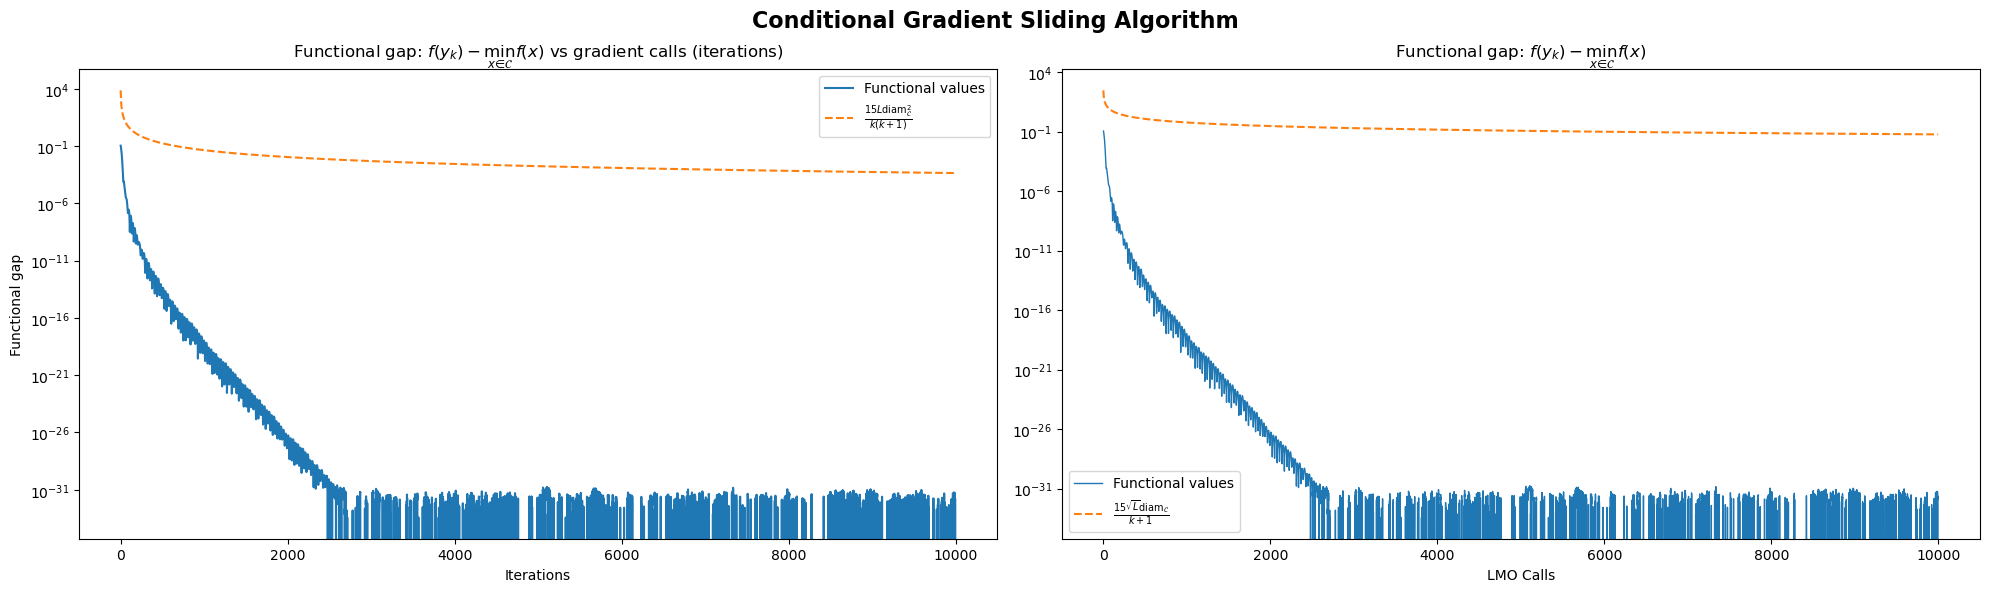

In [ ]:
Sliding.plot_convergence()

In [ ]:
# Run the algorithm with averaging and mismatch
SubgradientSliding.run(X0, n_steps=n_steps)

Conditional Gradient Sliding Progress:   0%|          | 0/10000 [00:00<?, ?it/s]/Users/cvntsf/My Drive/codes/fw_sliding/fw_functions.py:104: RuntimeWarning: invalid value encountered in scalar divide
  inner_step_size = inner_gap /(beta * (np.linalg.norm((inner_direction - u).flatten())**2))
Conditional Gradient Sliding Progress: 100%|██████████| 10000/10000 [00:00<00:00, 12109.10it/s]


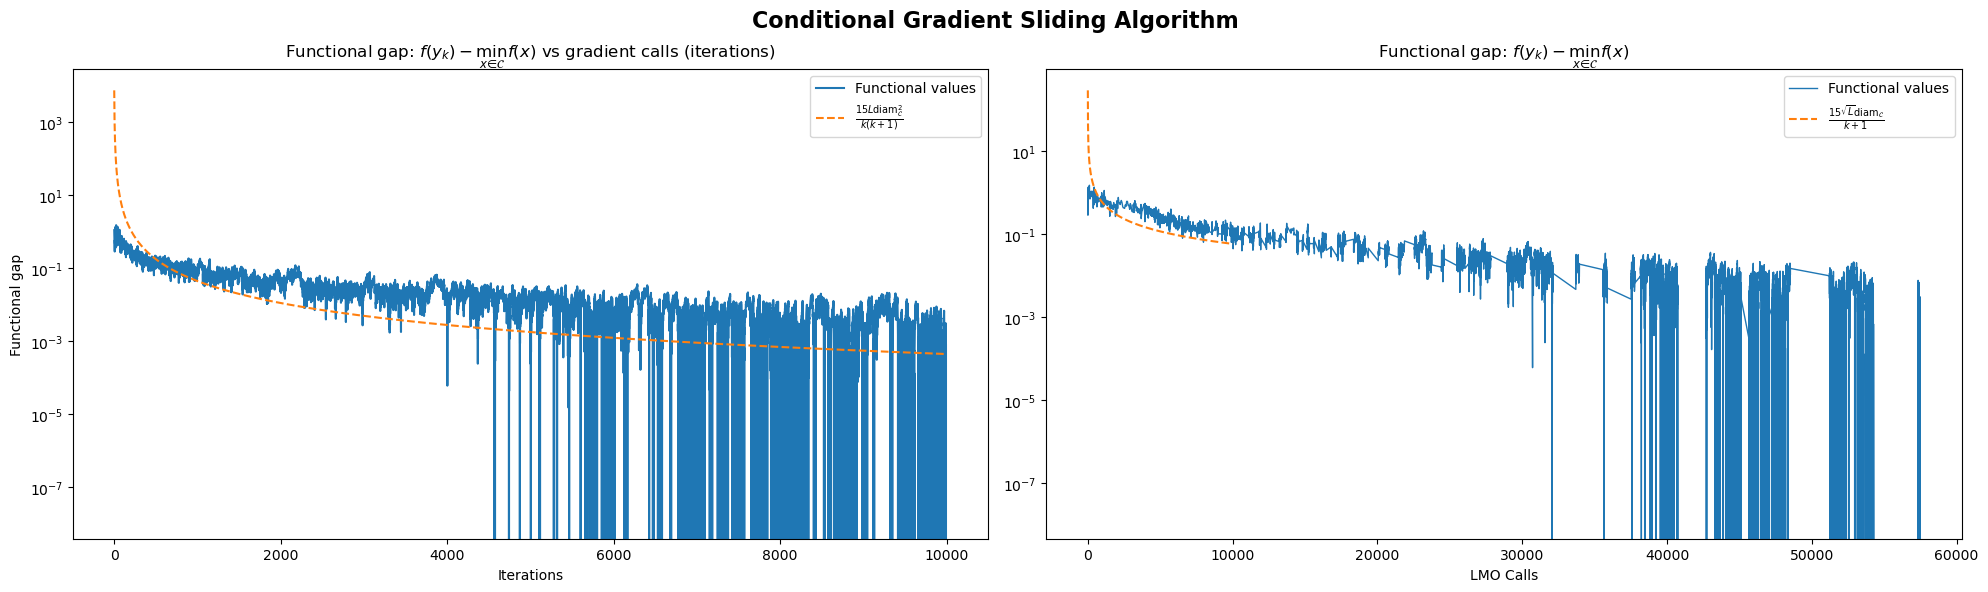

In [ ]:
SubgradientSliding.plot_convergence()

In [ ]:
class NonsmoothSlidingObjective(NonsmoothObjectiveFunction):
    def __init__(self, A, b, lipschitz):
        self.A = A
        self.b = b
        self.lipschitz = lipschitz
    
    def evaluate(self, X):
        return np.sum(np.abs((self.A @ X - self.b).flatten()))
    
    def moreau_grad(self, X, lam):
        return (1.0/lam) * self.A.T@((self.A@X) - self.b - soft_thresh((self.A@X) - self.b, lam))

In [ ]:
# Initialize the objective
objective_fn = NonsmoothSlidingObjective(A, b, lipschitz)

# Create an instance of the FrankWolfe class
NonsmoothSliding = NonsmoothSlidingFrankWolfe(objective_fn, lmo_fn, diam)

In [ ]:
# Run the algorithm with averaging and mismatch
NonsmoothSliding.run(X0, n_steps=n_steps, lam0=1.0)

Conditional Gradient Sliding Progress: 100%|██████████| 10000/10000 [00:00<00:00, 32520.03it/s]


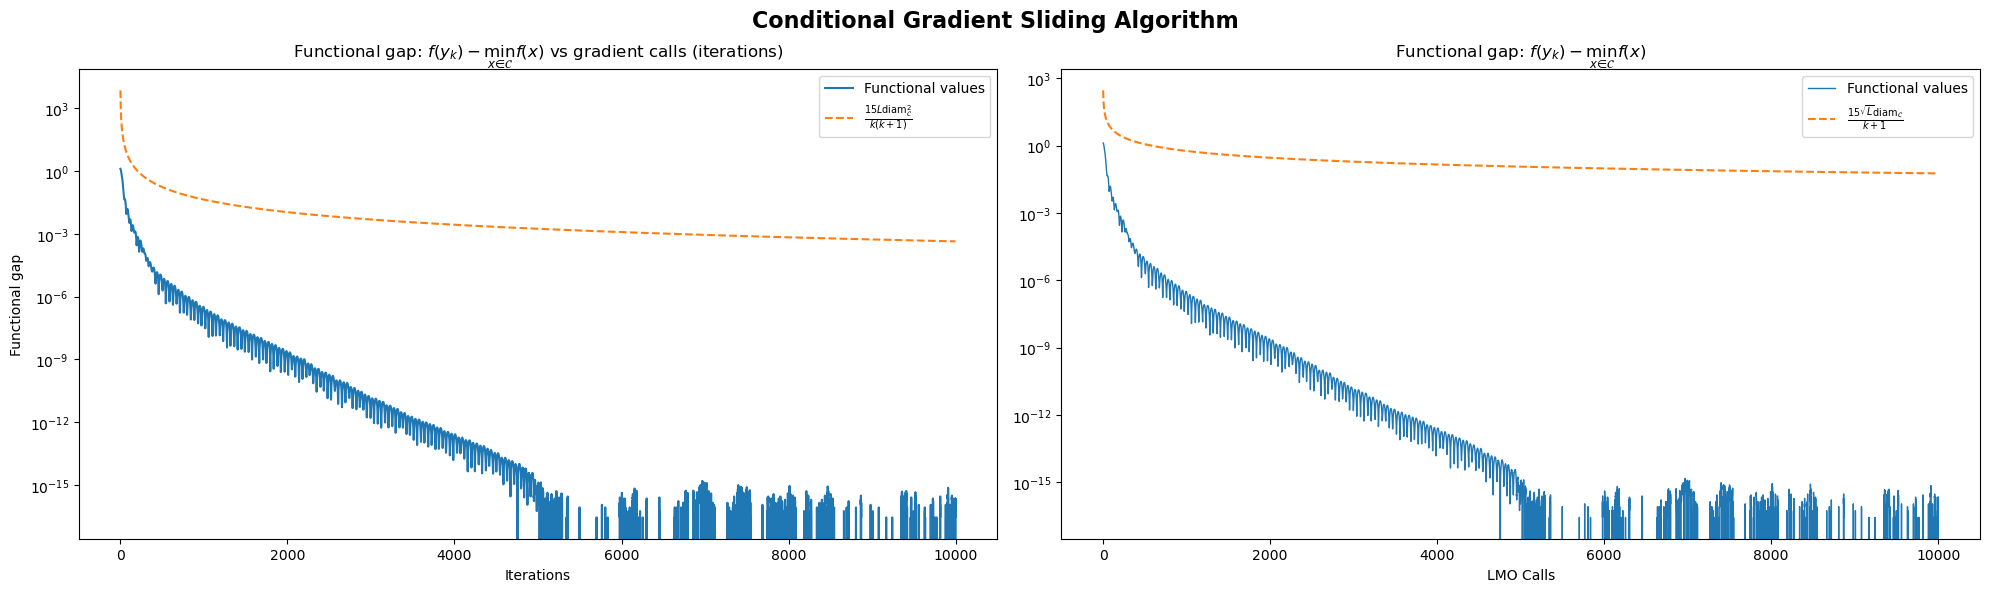

In [ ]:
NonsmoothSliding.plot_convergence()